
## Assignment: ML Student Performance Prediction and Model Evaluation (Day 18 & 19)
Using the provided Student Performance dataset, create one Jupyter/Google Colab notebook that follows a complete machine learning workflow, beginning with EDA to understand the dataset, identify numerical and categorical variables, examine distributions, relationships, correlations, missing values and potential outliers, and determine which factors appear to be related to exam_score. After the EDA, prepare the data for machine learning by selecting appropriate features, handling any required preprocessing, and defining exam_score as the regression target. Split the data into training and testing sets, train a Linear Regression model using relevant features such as study_hours_per_day, attendance_percentage, sleep_hours, social_media_hours, netflix_hours, exercise_frequency, mental_health_rating, and other suitable variables, generate predictions, and evaluate the model using the regression evaluation methods covered in class. Then create a classification problem by converting exam_score into a Pass/Fail target using 50 marks as the passing threshold, train an appropriate classification model using the same prepared dataset, generate predictions, and evaluate the model using a confusion matrix, accuracy, precision, recall, and F1-score. Finally, compare the model's performance on the training and testing data, discuss whether there are signs of overfitting or underfitting, identify the most important findings from your EDA and model results, and conclude with 5 meaningful insights about student performance


## 1. Dataset Inspection
load data set

In [1]:
import numpy as np 
import pandas as pd

In [2]:
data = pd.read_csv("Day18_19_student_habits_performance.csv")
data.head()

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   object 
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   object 
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   object 
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   object 
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       909 non-null    object 
 12  internet_quality               1000 non-null   ob

In [4]:
data.describe()

,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,exam_score
count,1000.0000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.4980,3.55010,2.505500,1.819700,84.131700,6.470100,3.042000,5.438000,69.601500
std,2.3081,1.46889,1.172422,1.075118,9.399246,1.226377,2.025423,2.847501,16.888564
min,17.0000,0.00000,0.000000,0.000000,56.000000,3.200000,0.000000,1.000000,18.400000
25%,18.7500,2.60000,1.700000,1.000000,78.000000,5.600000,1.000000,3.000000,58.475000
50%,20.0000,3.50000,2.500000,1.800000,84.400000,6.500000,3.000000,5.000000,70.500000
75%,23.0000,4.50000,3.300000,2.525000,91.025000,7.300000,5.000000,8.000000,81.325000
max,24.0000,8.30000,7.200000,5.400000,100.000000,10.000000,6.000000,10.000000,100.000000


In [5]:
data.isnull().sum()

student_id                        0
age                               0
gender                            0
study_hours_per_day               0
social_media_hours                0
netflix_hours                     0
part_time_job                     0
attendance_percentage             0
sleep_hours                       0
diet_quality                      0
exercise_frequency                0
parental_education_level         91
internet_quality                  0
mental_health_rating              0
extracurricular_participation     0
exam_score                        0
dtype: int64

In [6]:
data["parental_education_level"].value_counts()

parental_education_level
High School    392
Bachelor       350
Master         167
Name: count, dtype: int64

In [7]:
data["parental_education_level"] = data["parental_education_level"].fillna(data["parental_education_level"].mode()[0])
data["parental_education_level"].head()

0         Master
1    High School
2    High School
3         Master
4         Master
Name: parental_education_level, dtype: object

In [8]:
data.isnull().sum()

student_id                       0
age                              0
gender                           0
study_hours_per_day              0
social_media_hours               0
netflix_hours                    0
part_time_job                    0
attendance_percentage            0
sleep_hours                      0
diet_quality                     0
exercise_frequency               0
parental_education_level         0
internet_quality                 0
mental_health_rating             0
extracurricular_participation    0
exam_score                       0
dtype: int64

In [9]:
observer_num = data.select_dtypes(include='number')
observer_num

,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,exam_score
0,23,0.0,1.2,1.1,85.0,8.0,6,8,56.2
1,20,6.9,2.8,2.3,97.3,4.6,6,8,100.0
2,21,1.4,3.1,1.3,94.8,8.0,1,1,34.3
3,23,1.0,3.9,1.0,71.0,9.2,4,1,26.8
4,19,5.0,4.4,0.5,90.9,4.9,3,1,66.4
...,...,...,...,...,...,...,...,...,...
995,21,2.6,0.5,1.6,77.0,7.5,2,6,76.1
996,17,2.9,1.0,2.4,86.0,6.8,1,6,65.9
997,20,3.0,2.6,1.3,61.9,6.5,5,9,64.4
998,24,5.4,4.1,1.1,100.0,7.6,0,1,69.7


In [10]:
observer_num_list= observer_num.columns.tolist()
observer_num_list

['age',
 'study_hours_per_day',
 'social_media_hours',
 'netflix_hours',
 'attendance_percentage',
 'sleep_hours',
 'exercise_frequency',
 'mental_health_rating',
 'exam_score']

In [11]:
observer_obj = data.select_dtypes(include='object')
observer_obj

,student_id,gender,part_time_job,diet_quality,parental_education_level,internet_quality,extracurricular_participation
0,S1000,Female,No,Fair,Master,Average,Yes
1,S1001,Female,No,Good,High School,Average,No
2,S1002,Male,No,Poor,High School,Poor,No
3,S1003,Female,No,Poor,Master,Good,Yes
4,S1004,Female,No,Fair,Master,Good,No
...,...,...,...,...,...,...,...
995,S1995,Female,No,Fair,High School,Good,Yes
996,S1996,Female,Yes,Poor,High School,Average,Yes
997,S1997,Male,No,Good,Bachelor,Good,Yes
998,S1998,Male,Yes,Fair,Bachelor,Average,No


In [12]:
observer_obj_list= observer_obj.columns.tolist()
observer_obj_list

['student_id',
 'gender',
 'part_time_job',
 'diet_quality',
 'parental_education_level',
 'internet_quality',
 'extracurricular_participation']

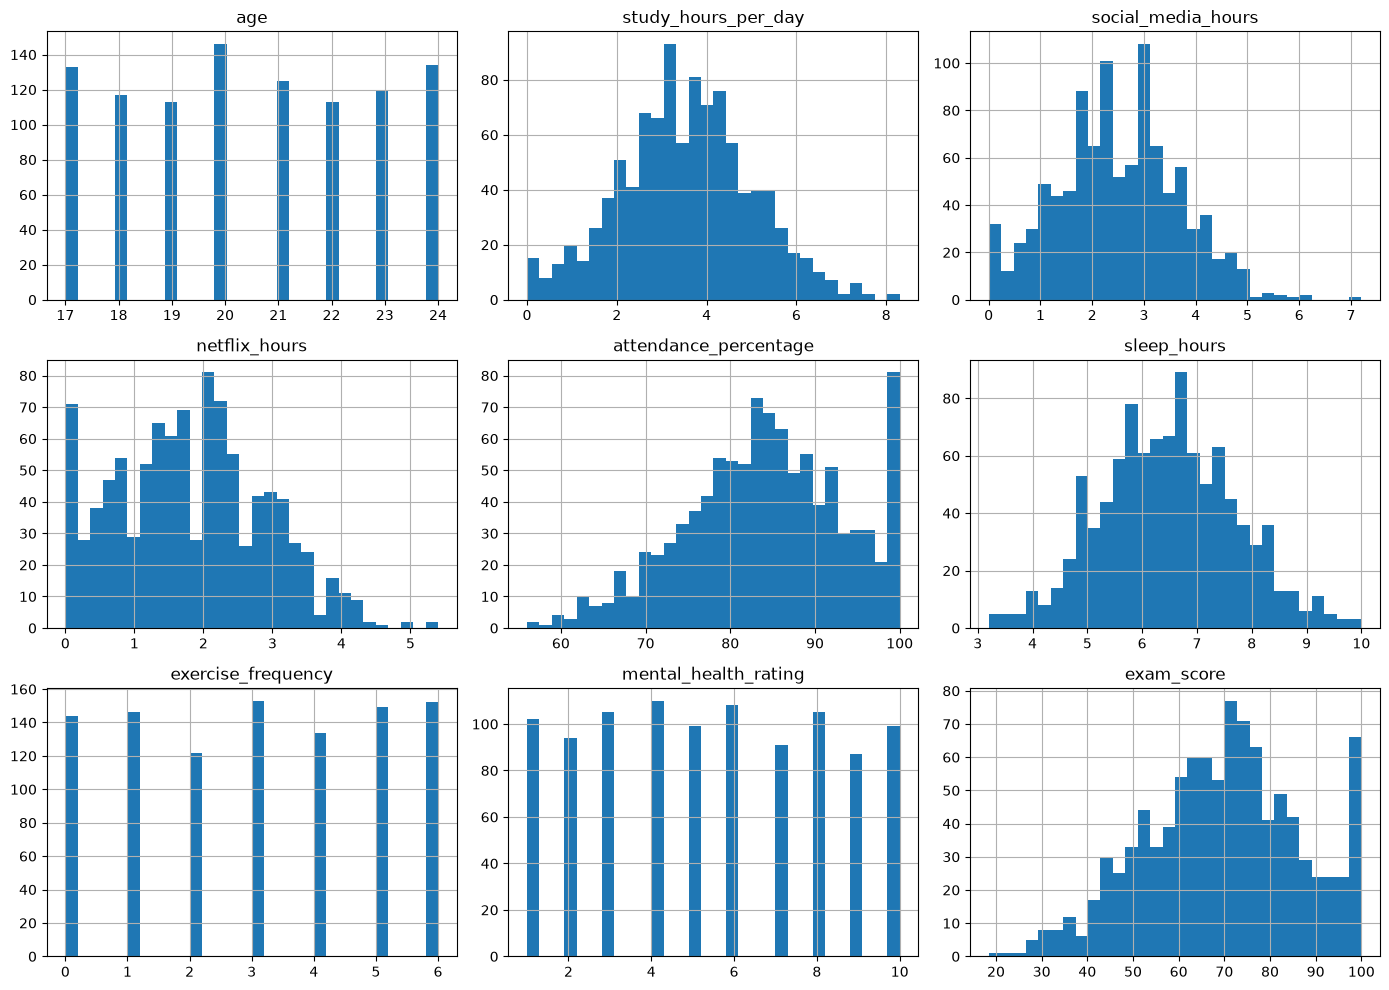

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns


observer_num.hist(figsize=(14, 10), bins=30)
plt.tight_layout()
plt.show()

## Relationships, Correlations, Outliers & Grouped Analysis (EDA continues)



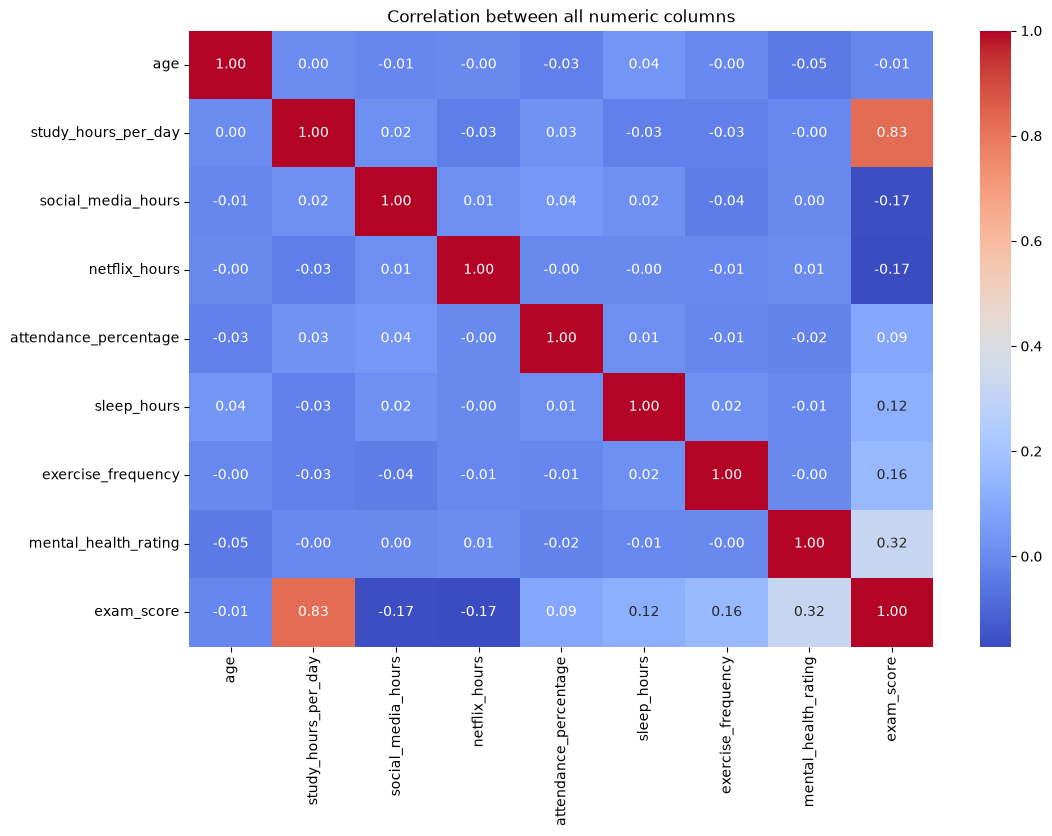

In [14]:

corr = observer_num.corr(numeric_only=True)

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation between all numeric columns")
plt.show()


In [15]:
corr_with_target = corr["exam_score"].sort_values(ascending=False)
print("Friends of exam_score (strongest first):")
print(corr_with_target)

Friends of exam_score (strongest first):
exam_score               1.000000
study_hours_per_day      0.825419
mental_health_rating     0.321523
exercise_frequency       0.160107
sleep_hours              0.121683
attendance_percentage    0.089836
age                     -0.008907
social_media_hours      -0.166733
netflix_hours           -0.171779
Name: exam_score, dtype: float64


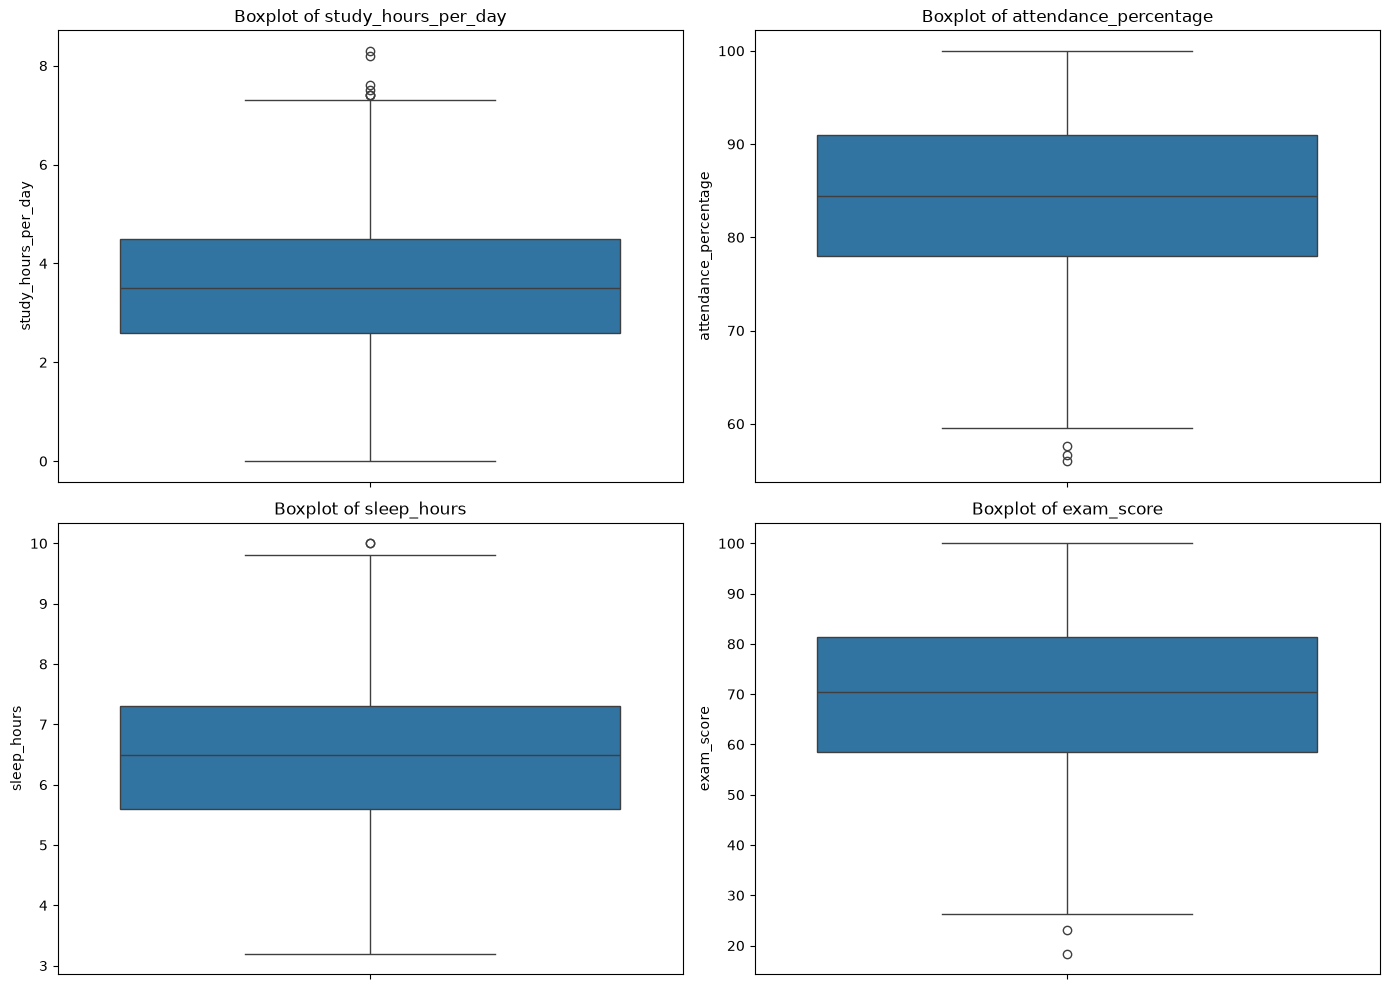

In [16]:

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
cols_to_check = ["study_hours_per_day", "attendance_percentage", "sleep_hours", "exam_score"]


for ax, col in zip(axes.ravel(), cols_to_check):
    sns.boxplot(data=observer_num, y=col, ax=ax)
    ax.set_title(f"Boxplot of {col}")
plt.tight_layout()
plt.show()


In [17]:

Q1 = observer_num.quantile(0.25)
Q3 = observer_num.quantile(0.75)
IQR = Q3 - Q1
outlier_count = ((observer_num < Q1 - 1.5 * IQR) | (observer_num > Q3 + 1.5 * IQR)).sum()
print("Outliers per column:")
print(outlier_count)

Outliers per column:
age                      0
study_hours_per_day      7
social_media_hours       5
netflix_hours            4
attendance_percentage    3
sleep_hours              2
exercise_frequency       0
mental_health_rating     0
exam_score               2
dtype: int64


In [ ]:

print(f"\nAverage marks by Extracurricular:\n{data.groupby('extracurricular_participation')['exam_score'].mean().round(2)}")


Average marks by Extracurricular:
extracurricular_participation
No     69.59
Yes    69.62
Name: exam_score, dtype: float64


In [19]:
print("Average marks by Gender:")
print(data.groupby('gender')['exam_score'].mean().round(2))

Average marks by Gender:
gender
Female    69.74
Male      69.37
Other     70.65
Name: exam_score, dtype: float64


In [20]:

print("Average marks by Part-Time Job:")
print(data.groupby('part_time_job')['exam_score'].mean().round(2))

Average marks by Part-Time Job:
part_time_job
No     69.84
Yes    68.74
Name: exam_score, dtype: float64


In [21]:
print("Average marks by Internet Quality:")
print(data.groupby('internet_quality')['exam_score'].mean().round(2))

Average marks by Internet Quality:
internet_quality
Average    70.64
Good       68.65
Poor       69.72
Name: exam_score, dtype: float64


In [22]:
print("Average marks by Extracurricular:")
print(data.groupby('extracurricular_participation')['exam_score'].mean().round(2))

Average marks by Extracurricular:
extracurricular_participation
No     69.59
Yes    69.62
Name: exam_score, dtype: float64


## Data Preparation for Machine Learning (Features + Target)


In [23]:

X = data.drop(columns=["student_id", "exam_score"])
y = data["exam_score"]

In [24]:
X = pd.get_dummies(X, columns=["gender", "part_time_job", "diet_quality",
                               "parental_education_level", "internet_quality",
                               "extracurricular_participation"], drop_first=True)
print("Features used:", list(X.columns))

Features used: ['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'attendance_percentage', 'sleep_hours', 'exercise_frequency', 'mental_health_rating', 'gender_Male', 'gender_Other', 'part_time_job_Yes', 'diet_quality_Good', 'diet_quality_Poor', 'parental_education_level_High School', 'parental_education_level_Master', 'internet_quality_Good', 'internet_quality_Poor', 'extracurricular_participation_Yes']


In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"We will teach on {X_train.shape[0]} students and test on {X_test.shape[0]} new students")

We will teach on 800 students and test on 200 new students


## Regression Problem: Predict exam_score (Linear Regression)


In [26]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

train_pred = model.predict(X_train)
test_pred = model.predict(X_test)
print("Predicted marks for 5 unseen students:", test_pred[:5].round(1))

Predicted marks for 5 unseen students: [66.2 75.1 78.1 73.3 61. ]


In [27]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np


mae = mean_absolute_error(y_test, test_pred)
mse = mean_squared_error(y_test, test_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, test_pred)


print(f"Average mistake: {mae:.2f} marks (MAE)")
print(f"RMSE: {rmse:.2f} marks (big mistakes punished more)")
print(f"R2: {r2:.3f} - we explain {r2*100:.1f}% of score differences")

Average mistake: 4.19 marks (MAE)
RMSE: 5.15 marks (big mistakes punished more)
R2: 0.897 - we explain 89.7% of score differences


In [35]:

train_r2 = r2_score(y_train, train_pred)
test_r2 = r2_score(y_test, test_pred)

print(f"Training R2: {train_r2:.3f} | Testing R2: {test_r2:.3f} | Gap: {train_r2-test_r2:.3f}")
if abs(train_r2 - test_r2) > 0.1:
    print("Sign of overfitting: too good on training, weak on new data")
else:
    print("good fit: no overfitting detected")

Training R2: 0.902 | Testing R2: 0.897 | Gap: 0.006
good fit: no overfitting detected


## Classification Problem: Pass or Fail (threshold = 50)


In [ ]:

y_class = (data["exam_score"] >= 50).astype(int)
print(f"{y_class.sum()} students passed, {(y_class == 0).sum()} students failed")

869 students passed, 131 students failed


In [30]:

y_class = (data["exam_score"] >= 50).astype(int)

print(f"Pass count: {y_class.sum()} | Fail count: {(y_class == 0).sum()}")

Pass count: 869 | Fail count: 131


In [31]:
from sklearn.model_selection import train_test_split

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X, y_class, test_size=0.2, random_state=42, stratify=y_class
)

print(f"Training samples: {X_train_c.shape[0]} | Testing samples: {X_test_c.shape[0]}")

Training samples: 800 | Testing samples: 200


In [32]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train_c, y_train_c)

clf_train_pred = clf.predict(X_train_c)
clf_test_pred = clf.predict(X_test_c)

c:\Users\harshil patel\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(


In [33]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

cm = confusion_matrix(y_test_c, clf_test_pred)
acc = accuracy_score(y_test_c, clf_test_pred)
prec = precision_score(y_test_c, clf_test_pred)
rec = recall_score(y_test_c, clf_test_pred)
f1 = f1_score(y_test_c, clf_test_pred)

print("Confusion Matrix:")
print(cm)
print(f"\nAccuracy:  {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall:    {rec:.3f}")
print(f"F1-Score:  {f1:.3f}")

Confusion Matrix:
[[ 22   4]
 [  4 170]]

Accuracy:  0.960
Precision: 0.977
Recall:    0.977
F1-Score:  0.977


In [34]:
train_acc = accuracy_score(y_train_c, clf_train_pred)

print(f"Training Accuracy: {train_acc:.3f} vs Testing Accuracy: {acc:.3f}")

if abs(train_acc - acc) < 0.05:
    print("Fit Assessment: Good fit, no significant overfitting observed.")
else:
    print("Fit Assessment: Discrepancy detected between training and test sets.")

Training Accuracy: 0.955 vs Testing Accuracy: 0.960
Fit Assessment: Good fit, no significant overfitting observed.


## Key Findings &  Meaningful Insights

**Most important EDA findings:**

- `study_hours_per_day` has the strongest relationship with exam_score (correlation = **+0.83**): more daily study hours clearly relate to higher marks.
- `netflix_hours` and `social_media_hours` are the two most negative correlates (**-0.17 each**): more screen time slightly pulls marks down.
- `parental_education_level` had **91 missing values**, which we filled with the most common value (mode).
- Categorical factors (gender, part-time job, internet quality, extracurriculars) made almost no difference to average marks - study habits matter far more.
- Data is clean: only a few outliers (max 7, in study hours), nothing extreme to fix.

**Model results:**

- Linear Regression: **R2 = 0.897** on test data (about 90% of score differences explained).
- Train R2 = 0.902 vs Test R2 = 0.897 -> gap of only ~0.01 -> **no overfitting**.
- Classification (Pass = 50+): Accuracy = **0.960**, Precision = **0.977**, Recall = **0.977**, F1 = **0.977**.

**5 Meaningful Insights about Student Performance:**

1. **Study hours are the #1 predictor** - the strongest correlation (0.83) with exam_score; increasing daily study time is the most effective change.
2. **Screen time drags scores down** - more social media and Netflix hours consistently co-exist with lower marks.
3. **Habits matter more than demographics** - gender, job status, internet quality and extracurriculars barely changed average scores.
4. **The model is strong and safe** - about 90% accuracy in predicting marks and 96% accuracy for Pass/Fail, with no signs of overfitting.
5. **Good mental health and exercise help a little** - both had a positive, modest correlation with scores; a balanced routine supports performance.
